In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Show plots inline (Jupyter)
%matplotlib inline

sm_path = "../data/smartmeter_15min_all_by_transformer_20251101_20251103_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"


In [ ]:
df_sm = pd.read_parquet(sm_path)

# Make sure timestamp is datetime and sorted
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_sm = df_sm.sort_values(["substation_id", "ts"])
df_sm.head()


,substation_id,transformer,ts,I_a,I_b,I_c,I_total,n_mps,per_completed
0,6,sp2,2025-11-01 12:00:00,313.205,301.675,314.45,929.330,13,0.146789
1,6,sp2,2025-11-01 12:15:00,313.960,308.090,304.64,926.690,13,0.146789
2,6,sp2,2025-11-01 12:30:00,308.135,292.250,323.26,923.645,13,0.146789
3,6,sp2,2025-11-01 12:45:00,297.700,291.240,329.16,918.100,13,0.146789
4,6,sp2,2025-11-01 13:00:00,299.580,282.385,290.93,872.895,13,0.146789


In [19]:
print("Shape (rows, cols):", df_sm.shape)
print("\nData types:")
print(df_sm.dtypes)

print("\nTime range:")
print("  From:", df_sm["ts"].min())
print("  To  :", df_sm["ts"].max())

print("\nNumber of unique substations:", df_sm["substation_id"].nunique())
print("List of substations (first 20):", df_sm["substation_id"].unique()[:20])

print("\nOverall current stats (A):")
print(df_sm[["I_a", "I_b", "I_c", "I_total"]].describe())

print("\nSmart meter completeness:")
print("  n_mps min/max:", df_sm["n_mps"].min(), "/", df_sm["n_mps"].max())
print("  per_completed describe:")
print(df_sm["per_completed"].describe())


Shape (rows, cols): (15633, 9)

Data types:
substation_id             int32
transformer              object
ts               datetime64[ns]
I_a                     float64
I_b                     float64
I_c                     float64
I_total                 float64
n_mps                     int64
per_completed           float64
dtype: object

Time range:
  From: 2025-11-01 12:00:00
  To  : 2025-11-03 12:00:00

Number of unique substations: 68
List of substations (first 20): [  6  29  55  74  76 173 176 202 246 263 303 383 411 537 579 613 615 662
 670 688]

Overall current stats (A):
                I_a           I_b           I_c       I_total
count  15633.000000  15633.000000  15633.000000  15633.000000
mean     258.530659    153.416992    149.106182    561.053833
std      226.647619    186.458580    185.036642    555.909349
min        0.000000      0.000000      0.000000      0.000000
25%       95.100000     47.850000     45.680000    225.000000
50%      207.500000     91.870000   

In [20]:
substation_stats = (
    df_sm
    .groupby("substation_id")
    .agg(
        mean_I_a=("I_a", "mean"),
        mean_I_b=("I_b", "mean"),
        mean_I_c=("I_c", "mean"),
        mean_I_total=("I_total", "mean"),
        max_I_total=("I_total", "max"),
        mean_per_completed=("per_completed", "mean"),
        n_samples=("ts", "count"),
    )
    .reset_index()
)

substation_stats.head()


,substation_id,mean_I_a,mean_I_b,mean_I_c,mean_I_total,max_I_total,mean_per_completed,n_samples
0,6,264.999482,256.958549,254.455311,776.413342,1193.73,0.146789,193
1,29,283.466062,248.753083,256.843886,789.063031,2014.33,0.103448,193
2,55,322.834171,274.004741,243.657604,840.496516,2400.85,0.624688,386
3,74,152.566593,135.976347,130.231891,418.774832,769.00,0.412500,386
4,76,253.859534,199.837047,187.912383,641.608964,894.59,0.375839,193


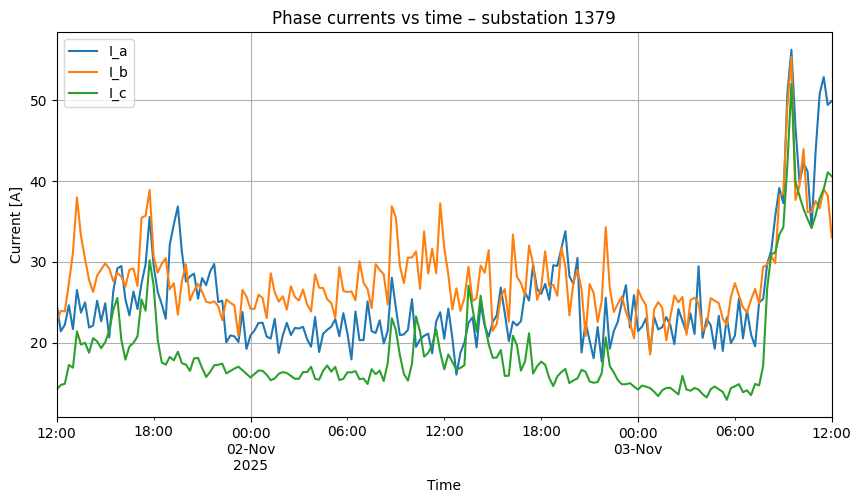

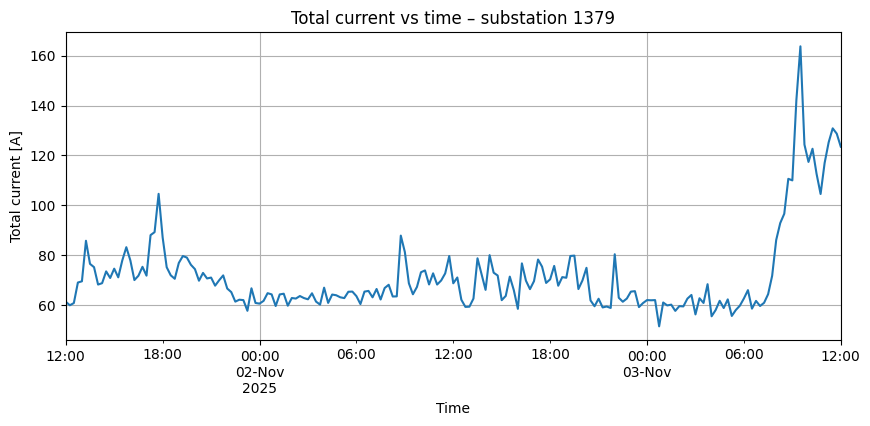

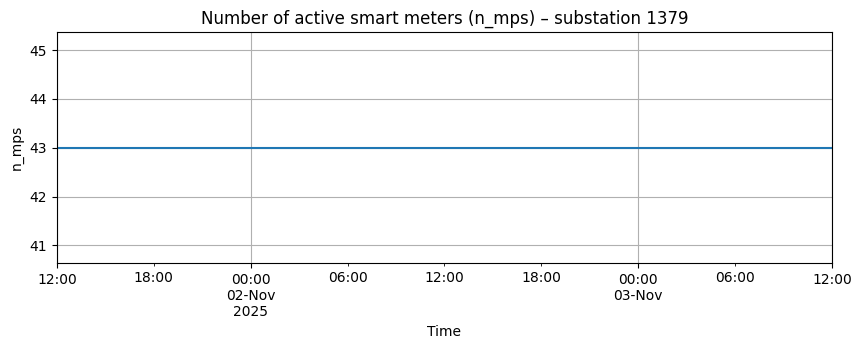

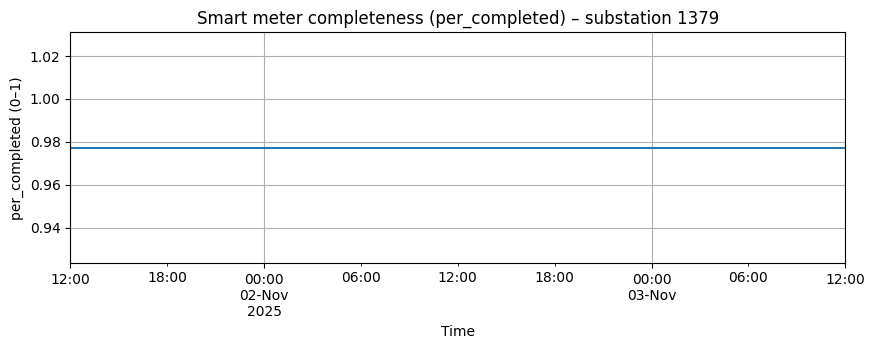

avg total current: 71.96316062176166


In [28]:
sub_id = 1379  # <-- change this
trafo_id = "sp1"

df_one = df_sm[(df_sm["substation_id"] == sub_id) & (df_sm["transformer"] == trafo_id)].copy()
df_one = df_one.sort_values("ts").set_index("ts")

# ---- Phase currents ----
df_one[["I_a", "I_b", "I_c"]].plot(figsize=(10, 5))
plt.title(f"Phase currents vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Current [A]")
plt.grid(True)
plt.show()

# ---- Total current ----
df_one["I_total"].plot(figsize=(10, 4))
plt.title(f"Total current vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Total current [A]")
plt.grid(True)
plt.show()

# ---- n_mps ----
df_one["n_mps"].plot(figsize=(10, 3))
plt.title(f"Number of active smart meters (n_mps) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("n_mps")
plt.grid(True)
plt.show()

# ---- per_completed ----
df_one["per_completed"].plot(figsize=(10, 3))
plt.title(f"Smart meter completeness (per_completed) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("per_completed (0–1)")
plt.grid(True)
plt.show()

print("avg total current:", df_one["I_total"].mean())


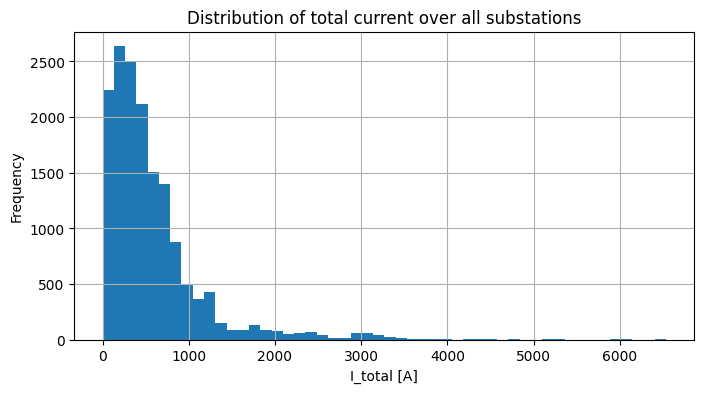

In [22]:
df_sm["I_total"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of total current over all substations")
plt.xlabel("I_total [A]")
plt.grid(True)
plt.show()


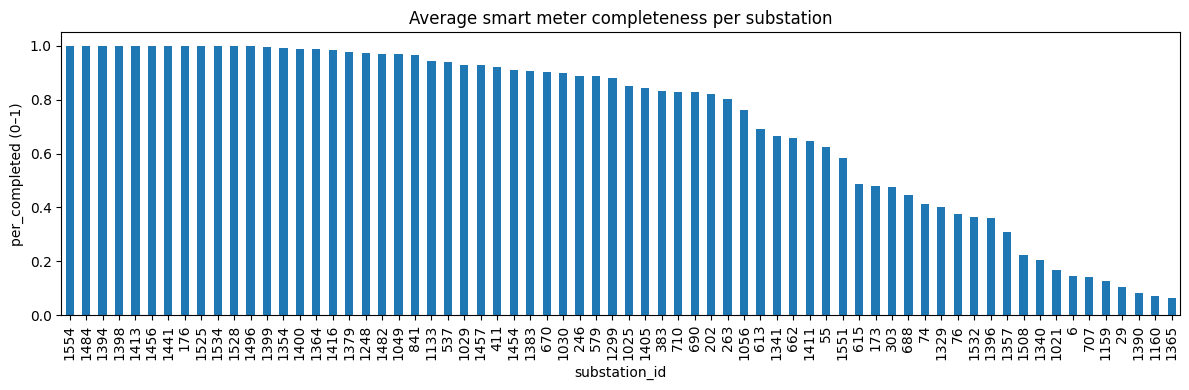

In [23]:
avg_comp = (
    df_sm.groupby("substation_id")["per_completed"]
    .mean()
    .sort_values(ascending=False)
)

avg_comp.plot(kind="bar", figsize=(12, 4))
plt.title("Average smart meter completeness per substation")
plt.ylabel("per_completed (0–1)")
plt.xlabel("substation_id")
plt.tight_layout()
plt.show()


Cutoff = 0.90: keeping 31 of 68 substations


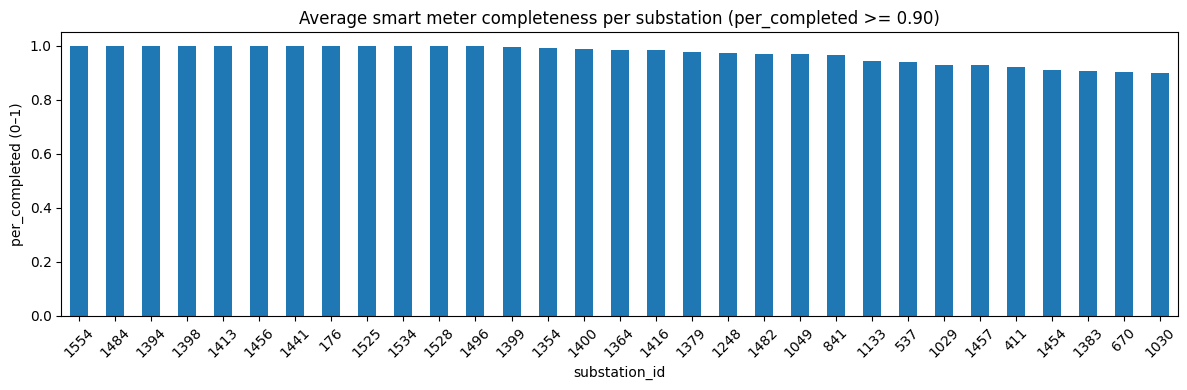

In [24]:
# Set cutoff threshold (0.0 - 1.0). Substations with avg per_completed < cutoff will be excluded.
cutoff = 0.9

filtered = avg_comp[avg_comp >= cutoff]

print(f"Cutoff = {cutoff:.2f}: keeping {len(filtered)} of {len(avg_comp)} substations")
if filtered.empty:
    print("No substations meet the cutoff. Lower the threshold.")
else:
    ax = filtered.plot(kind="bar", figsize=(12, 4))
    ax.set_title(f"Average smart meter completeness per substation (per_completed >= {cutoff:.2f})")
    ax.set_ylabel("per_completed (0–1)")
    ax.set_xlabel("substation_id")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()